# Day 5 — Centralized 1D CNN baseline

This baseline trains on the existing training partition and monitors on validation. It loads only those two partition directories; no test data is opened. It uses the documented 15 distinct Day 2 source labels without balancing or augmentation.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import matplotlib.pyplot as plt
import torch
ROOT = Path.cwd()
if not (ROOT / 'configs/training/centralized_cnn_v1.json').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.models.cnn1d import ECG1DCNN, count_trainable_parameters
from src.models.train_cnn import load_training_configuration, load_train_validation_datasets, train_model
training_config = load_training_configuration(ROOT / 'configs/training/centralized_cnn_v1.json')
train_ds, validation_ds, class_to_index = load_train_validation_datasets(ROOT / 'data/splits/mitbih_v1', ROOT / 'configs/preprocessing/mitbih_v1.json')
print('Input per segment on disk: (216 samples, 2 channels); model input: (2 channels, 216 samples)')
print('Number of classes:', len(class_to_index), '| class_to_index:', class_to_index)
print('Training segments/records:', len(train_ds), len(train_ds.record_ids), '| validation segments/records:', len(validation_ds), len(validation_ds.record_ids))
print('Training class counts:', train_ds.class_counts)
print('Validation class counts:', validation_ds.class_counts)

Input per segment on disk: (216 samples, 2 channels); model input: (2 channels, 216 samples)
Number of classes: 15 | class_to_index: {'/': 0, 'A': 1, 'E': 2, 'F': 3, 'J': 4, 'L': 5, 'N': 6, 'Q': 7, 'R': 8, 'S': 9, 'V': 10, 'a': 11, 'e': 12, 'f': 13, 'j': 14}
Training segments/records: 77550 33 | validation segments/records: 16351 8
Training class counts: {'/': 3407, 'A': 2418, 'E': 106, 'F': 782, 'J': 80, 'L': 3948, 'N': 53489, 'Q': 29, 'R': 7255, 'S': 2, 'V': 5049, 'a': 28, 'e': 16, 'f': 722, 'j': 219}
Validation class counts: {'/': 1542, 'A': 78, 'F': 7, 'J': 3, 'L': 2123, 'N': 11342, 'V': 870, 'a': 116, 'f': 260, 'j': 10}


## Model creation and summary
The network uses Conv1D/BatchNorm/ReLU blocks, two max-pooling operations, adaptive global average pooling, dropout, and a 15-unit linear output layer. The loss consumes logits directly.

In [2]:
model = ECG1DCNN(num_classes=len(class_to_index), dropout=training_config['dropout'])
print(model)
print('Trainable parameters:', count_trainable_parameters(model))
with torch.no_grad(): print('Output shape for a 4-example batch:', tuple(model(torch.zeros(4, 2, 216)).shape))

ECG1DCNN(
  (features): Sequential(
    (0): Conv1d(2, 16, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_features=64, out_features=15, bias=T

## Training and validation monitoring
Each epoch uses the training loader for gradient updates. The validation loader is evaluated without gradients. The saved checkpoint is the epoch with the lowest validation loss. No validation classes are rebalanced.

In [3]:
trained_model, run = train_model(train_ds, validation_ds, class_to_index, training_config, output_root=ROOT / 'results')
print('Saved model:', run['model_path'])
print('Best validation-loss epoch:', run['best_epoch_by_validation_loss'])
print('Last epoch metrics:', run['history'][-1])
print('Best checkpoint validation loss:', run['best_validation_loss'])

{"epoch": 1, "train_loss": 0.7917663991789445, "train_accuracy": 0.8195228884590586, "validation_loss": 1.2786230777252063, "validation_accuracy": 0.6853403461561984, "validation_macro_f1_all_labels": 0.1737207554842273}


{"epoch": 2, "train_loss": 0.27804004081635997, "train_accuracy": 0.9356028368794326, "validation_loss": 1.4897654526503865, "validation_accuracy": 0.6262613907406275, "validation_macro_f1_all_labels": 0.08193776352410899}


{"epoch": 3, "train_loss": 0.20959852924160924, "train_accuracy": 0.9486782720825274, "validation_loss": 1.4255257186725754, "validation_accuracy": 0.7125558069842823, "validation_macro_f1_all_labels": 0.08931846037645544}


{"epoch": 4, "train_loss": 0.17976589305757476, "train_accuracy": 0.9549580915538363, "validation_loss": 1.677194717819702, "validation_accuracy": 0.603021221943612, "validation_macro_f1_all_labels": 0.09015210854182035}


{"epoch": 5, "train_loss": 0.15945835101881156, "train_accuracy": 0.9597549967762734, "validation_loss": 1.893881215519748, "validation_accuracy": 0.700385297535319, "validation_macro_f1_all_labels": 0.1350711611846263}
Saved model: C:\Users\adni\Desktop\AI_Software_Engineering_Projects\blockchain-fl-arrhythmia-checkout\results\models\centralized_cnn_v1.pt
Best validation-loss epoch: 1
Last epoch metrics: {'epoch': 5, 'train_loss': 0.15945835101881156, 'train_accuracy': 0.9597549967762734, 'validation_loss': 1.893881215519748, 'validation_accuracy': 0.700385297535319, 'validation_macro_f1_all_labels': 0.1350711611846263}
Best checkpoint validation loss: 1.2786230777252063


## Training history
Macro-F1 is computed over all 15 configured labels with zero for labels with no validation support. Such scores need cautious interpretation: the validation partition lacks several classes under the fixed record-group split.

,train_loss,train_accuracy,validation_loss,validation_accuracy,validation_macro_f1_all_labels
epoch,,,,,
1,0.791766,0.819523,1.278623,0.685340,0.173721
2,0.278040,0.935603,1.489765,0.626261,0.081938
3,0.209599,0.948678,1.425526,0.712556,0.089318
4,0.179766,0.954958,1.677195,0.603021,0.090152
5,0.159458,0.959755,1.893881,0.700385,0.135071


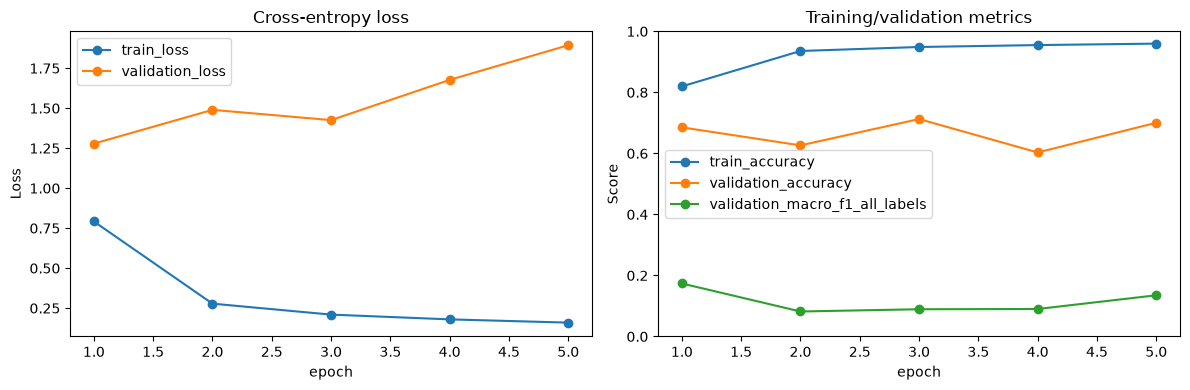

History JSON: results/metrics/centralized_cnn_v1_history.json
History CSV: results/metrics/centralized_cnn_v1_history.csv


In [4]:
history_df = pd.DataFrame(run['history']).set_index('epoch')
display(history_df)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
history_df[['train_loss','validation_loss']].plot(ax=axes[0], marker='o'); axes[0].set_title('Cross-entropy loss'); axes[0].set_ylabel('Loss')
history_df[['train_accuracy','validation_accuracy','validation_macro_f1_all_labels']].plot(ax=axes[1], marker='o'); axes[1].set_title('Training/validation metrics'); axes[1].set_ylabel('Score'); axes[1].set_ylim(0,1)
fig.tight_layout(); fig.savefig(ROOT / 'results/figures/centralized_cnn_v1_training.png', dpi=160); plt.show()
print('History JSON: results/metrics/centralized_cnn_v1_history.json')
print('History CSV: results/metrics/centralized_cnn_v1_history.csv')